In [42]:
import pandas as pd
import numpy as np 
import  matplotlib.pyplot as plt
from vmdpy import VMD
from scipy.io import loadmat
from scipy.signal import hilbert
from scipy.signal import detrend

In [43]:
def data_load(file_path,chanel,start_index=0,slice_lenth=None):
    '''
    
    :param file_path:文件路径
    :param chanel: 数据通道
    :param start_index: 数据切片的起始位置
    :param slice_lenth: 数据切片的长度
    :return: 
    '''
    data=loadmat(file_path)
    data=data[chanel].flatten()
    data=data[start_index:start_index+slice_lenth]
    return data

In [44]:
def get_VMD(data, K,tol,alpha, tau=0, DC=0, init=1, ):
    '''
    :param data:原始数据
    :param f: 采样频率
    :param alpha: 惩罚系数
    :param tau: 
    :param K: 模态淑
    :param DC: 
    :param init: 
    :param tol: 收敛值
    :return: 
    '''
    alpha = alpha;     
    tau = tau;            
    K = K;            
    DC = DC;             
    init = init;           
    tol = tol;
    u, u_hat, omega = VMD(data, alpha, tau, K, DC, init, tol)
    final_omegas = omega[-1, :] 
    sort_index = np.argsort(final_omegas)
    
    # 重排数据
    omega = omega[:, sort_index]
    u_hat = u_hat[:, sort_index]      # 注意：u_hat 通常是 (L, K)，需确认维度
    u = u[sort_index, :]              # u 通常是 (K, L)
    
    return u,u_hat,omega

In [45]:
def plot_IMF(u,u_hat,omega,K,data,f):
        # 2. 时域向量
    Fs=f
    L = len(data)
    t = np.arange(L) / Fs
    
    # 3. 频域分析 (FFT)
    # 计算 FFT 并取单边谱
    P2 = np.abs(np.fft.fft(data)) / L
    P1 = P2[:L//2]
    P1[1:] = 2 * P1[1:]  # 除直流分量外，幅值翻倍
    frequ = np.linspace(0, Fs/2, L//2)
    linestyles = ['b', 'g', 'm', 'c', 'r', 'k']
    labels = [f'IMF{k+1}' for k in range(K)]
    
    # ==========================================
    # 1. IMF 时域分析 (Time Domain)
    # ==========================================
    plt.figure(figsize=(10, 8))
    for k in range(K):
        plt.subplot(K, 1, k+1)
        plt.plot(t, u[k, :], linestyles[k % len(linestyles)], linewidth=1)
        plt.ylabel('Amplitude/g')
        plt.title(f'{labels[k]}')
        plt.grid(True, linestyle='--', alpha=0.3)
        # 最后一个子图加 xlabel
        if k == K - 1:
            plt.xlabel('t/s')
    plt.suptitle('IMF Components (Time Domain)', fontsize=14)
    plt.tight_layout()
    
    # ==========================================
    # 2. IMF 频域分析 (Frequency Domain)
    # ==========================================
    plt.figure(figsize=(10, 6))
    # 绘制原始信号频谱 (黑色虚线)
    plt.plot(frequ, P1, 'k:', label='Original Signal', linewidth=1.5)
    
    # 绘制各 IMF 频谱
    # 注意：MATLAB 代码中 abs(u_hat(L/2+1:end,k))/L 对应的是单边谱的后半段映射
    # 假设 u_hat 是双边谱，我们需要取正频率部分并归一化
    for k in range(K):
        # 提取正频率部分 (假设 u_hat 第一维是频率点，从0到Fs)
        # MATLAB: L/2+1:end 对应 Python: L//2 : 
        spectrum = np.abs(u_hat[L//2:, k]) / L 
        # 确保长度与 frequ 一致 (有时 FFT 点数会有细微差别，这里做截断或填充)
        length_match = min(len(spectrum), len(frequ))
        plt.plot(frequ[:length_match], spectrum[:length_match], 
                 linestyles[k % len(linestyles)], label=labels[k], linewidth=1)
    
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude')
    plt.title('Spectrum Comparison: Original vs IMFs')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.xlim(0, 6000) # 可根据需要调整显示范围
    plt.tight_layout()
    
    # ==========================================
    # 3. 中心频率迭代收敛过程 (Convergence)
    # ==========================================
    plt.figure(figsize=(10, 6))
    n_iter = omega.shape[0] # 迭代次数
    y_axis = np.arange(1, n_iter + 1) # Y轴为迭代次数 (1 到 N)
    
    for k in range(K):
        freq_vals = omega[:, k] * Fs 
        plt.plot(freq_vals, y_axis, linestyles[k % len(linestyles)], 
                 marker='.', markersize=4, label=labels[k])
    
    plt.xlabel('Center Frequency (Hz)')
    plt.ylabel('Iteration Number')
    plt.title('Convergence of Center Frequencies')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    # 反转Y轴，让第1次迭代在最上面 (可选，看个人习惯，MATLAB默认是下小上大)
    # plt.gca().invert_yaxis() 
    plt.tight_layout()
    plt.show()
        
    analytic_signal = hilbert(u, axis=1) 
    envelope = np.abs(analytic_signal)
    
    # 2. 去直流分量 (减去均值)
    # MATLAB: mean(u_h_bao_luo) 默认按列求平均 (dim=1)，结果是 (1, K)
    # Python: mean(axis=1) 得到 (K,)，需要 reshape 为 (K, 1) 以便广播相减
    mean_envelope = np.mean(envelope, axis=1, keepdims=True) 
    envelope_detrended = envelope - mean_envelope
    envelope_detrended = detrend(envelope_detrended, type='linear')
    # 3. FFT 频谱分析
    # 对去直流后的包络做 FFT
    fft_envelope = np.fft.fft(envelope_detrended, axis=1)
    
    # 取单边谱 (只取前 L/2 个点)
    L_half = L // 2
    P2_env = np.abs(fft_envelope[:, :L_half]) / L  # 归一化
    
    # 幅值修正 (乘以2)，注意：第0个点(DC)和第L/2个点(Nyquist)不乘
    # Python 索引: 0 是 DC, 1 到 L/2-1 是正频率
    P1_env = P2_env.copy()
    P1_env[:, 1:L_half-1] = 2 * P1_env[:, 1:L_half-1]
    
    # 此时 P1_env 的形状是 (K, L/2)
    # 对应的频率轴应该是 frequ (假设 frequ 长度也是 L/2)
    
    # ==========================================
    # 绘图
    # ==========================================
    plt.figure(figsize=(10, 2 * K))
    
    for k in range(K):
        plt.subplot(K, 1, k+1)
        
        # 提取当前分量的包络谱数据
        # P1_env[k, :] 对应 MATLAB 的 P1_VMD_bao_luo(:, k) (注意 MATLAB 这里是列向量)
        # 我们的 P1_env 是 (K, L/2)，所以取行
        spectrum_data = P1_env[k, :]
        
        # 确保频率轴和数据长度一致
        freq_axis = frequ[:len(spectrum_data)]
        
        plt.plot(freq_axis, spectrum_data, linestyles[k % len(linestyles)], linewidth=1)
        
        plt.title(f'IMF{k+1} Envelope Spectrum')
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('Amplitude')
        plt.legend([f'IMF{k+1}'])
        plt.grid(True, linestyle='--', alpha=0.3)
        
        # 关键：限制 X 轴范围为 0-1000 Hz (对应 MATLAB 的 axis([0 1000 ...]))
        # 同时自动调整 Y 轴范围以适配数据
        plt.xlim(0, 1000)
        
        # 可选：如果数据太小，可以设置 ylim 自动适应，或者像 MATLAB 一样手动设
        # plt.ylim(min(spectrum_data), max(spectrum_data)) 
    
    plt.suptitle('Envelope Spectrum of IMF Components', fontsize=14)
    plt.tight_layout()
    plt.show()

In [46]:
file_path='../../数据集/CRWU/12k Drive End Bearing Fault Data/Inner Race/0007/IR007_0.mat'
data=data_load(file_path,chanel='X105_DE_time',start_index=10000,slice_lenth=4096)

In [47]:
u,u_hat,omega=get_VMD(data,K=4,tol=1e-7,alpha=2000,tau=0,init=1,DC=0)


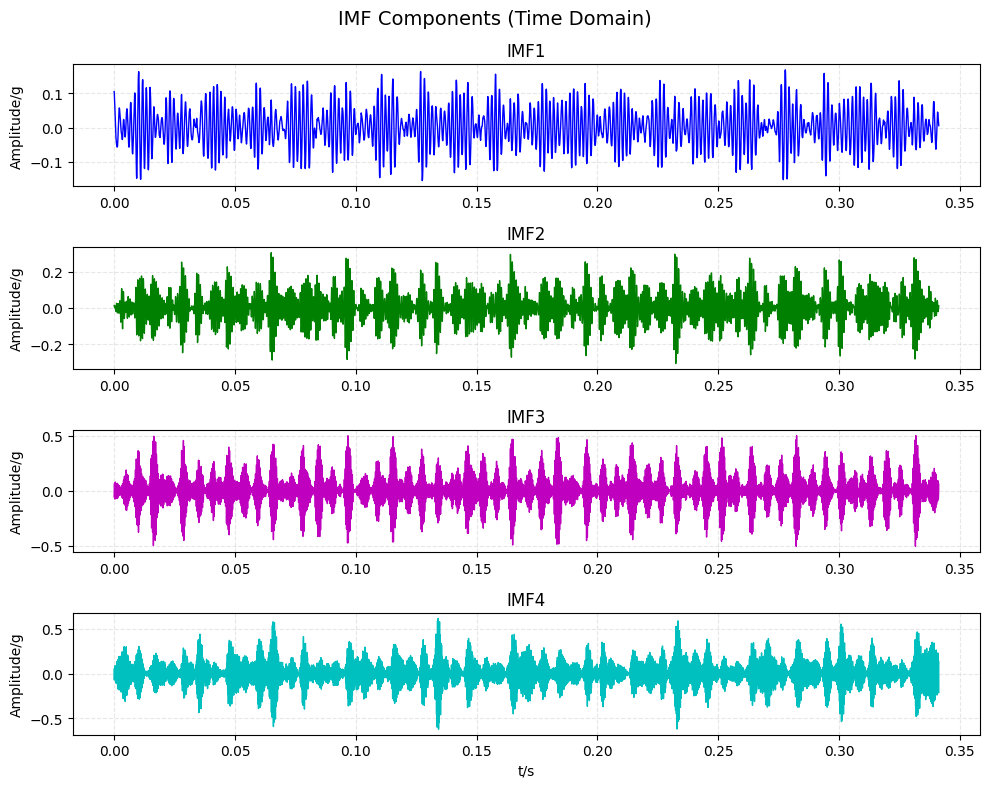

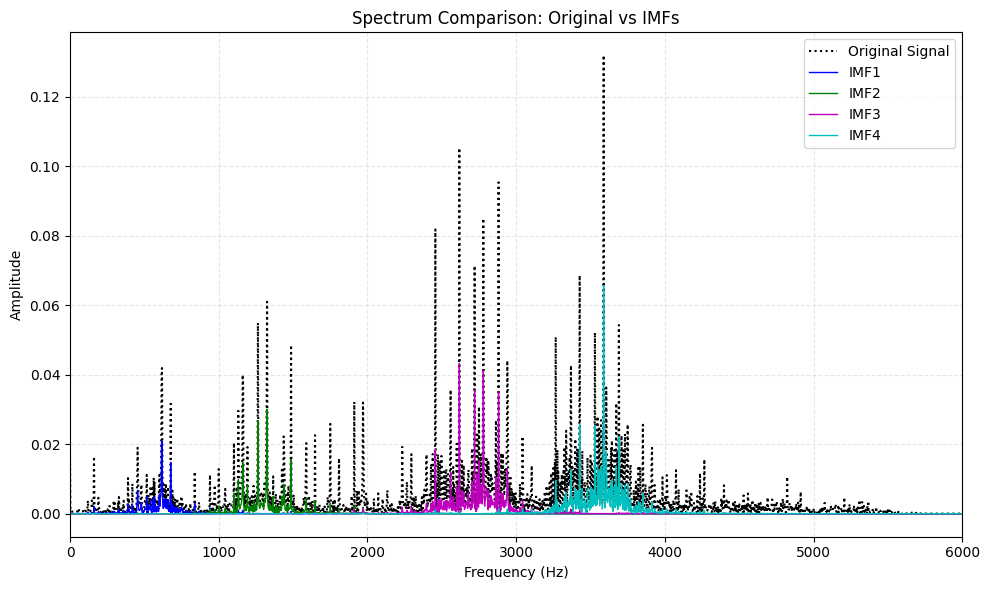

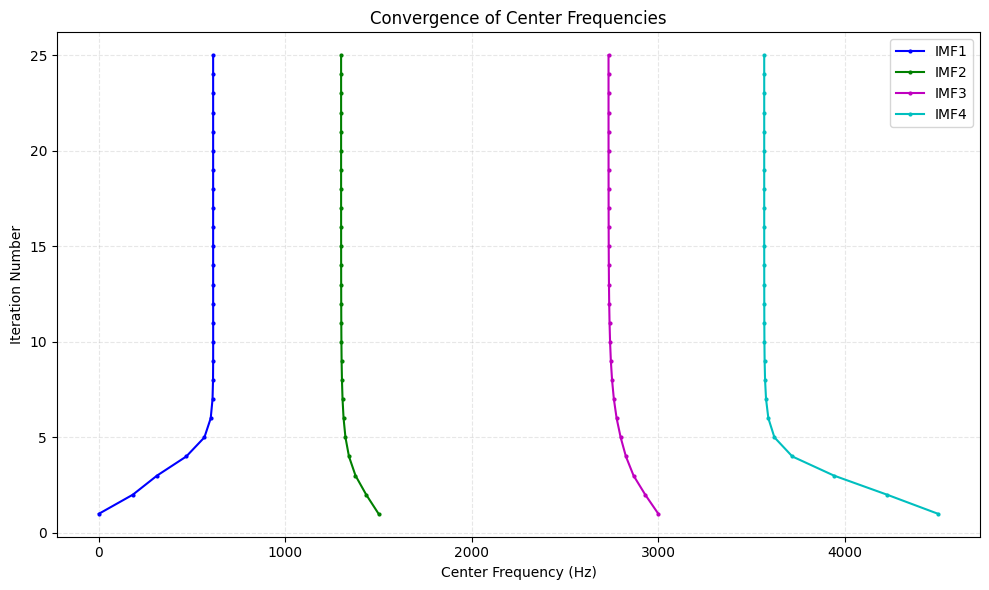

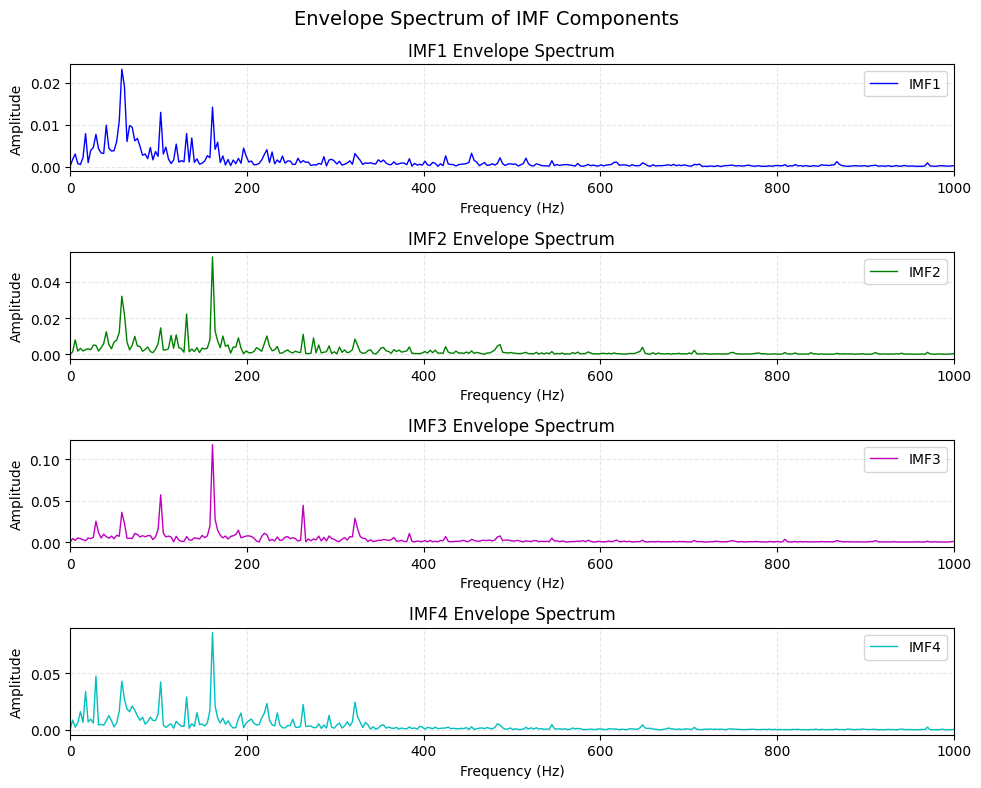

In [48]:
plot_IMF(u,u_hat,omega,K=4,data=data,f=12000)

In [49]:
data=loadmat('../../数据集/CRWU/12k Drive End Bearing Fault Data/Outer Race/Centered/0007/OR007@6_0.mat')
data=data['X130_DE_time'].flatten()
data=data[10000:10000+2**14]

In [50]:
u,u_hat,omega=get_VMD(data,K=4,tol=1e-7,alpha=2000,tau=0,init=1,DC=0)


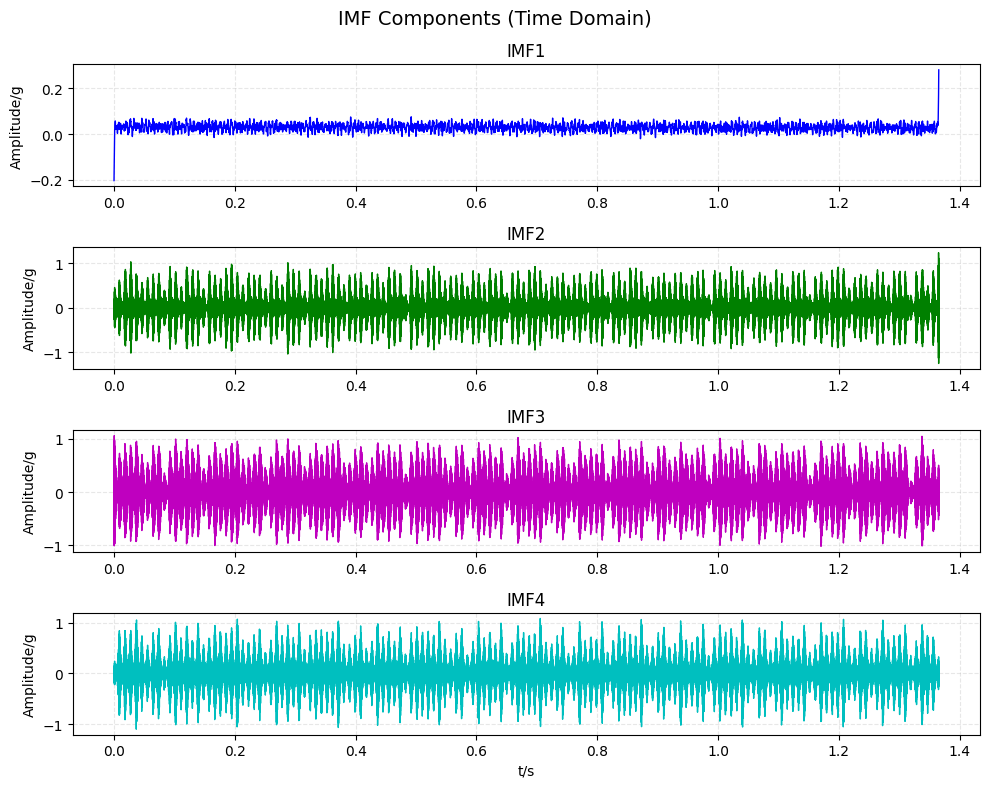

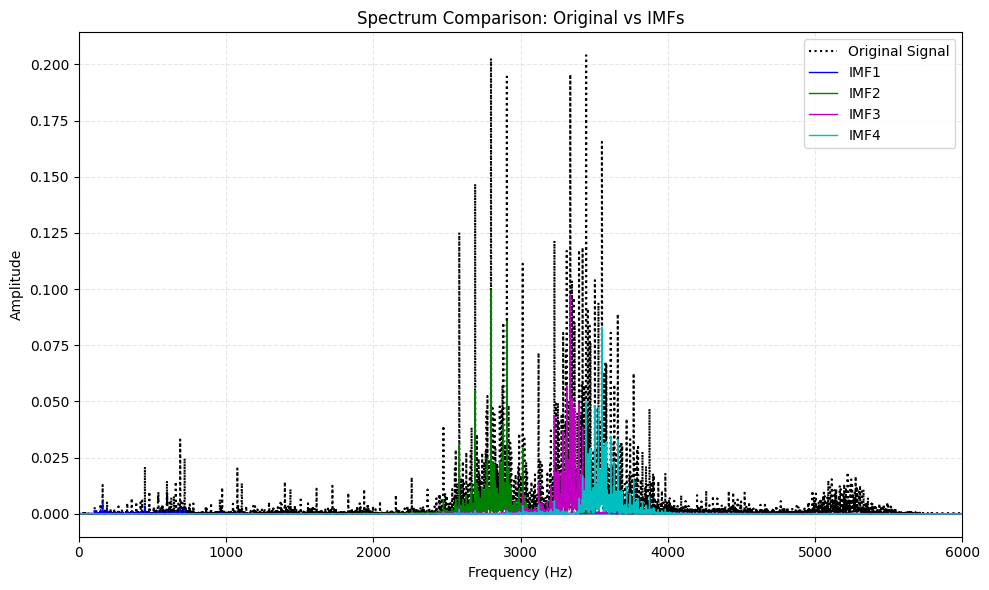

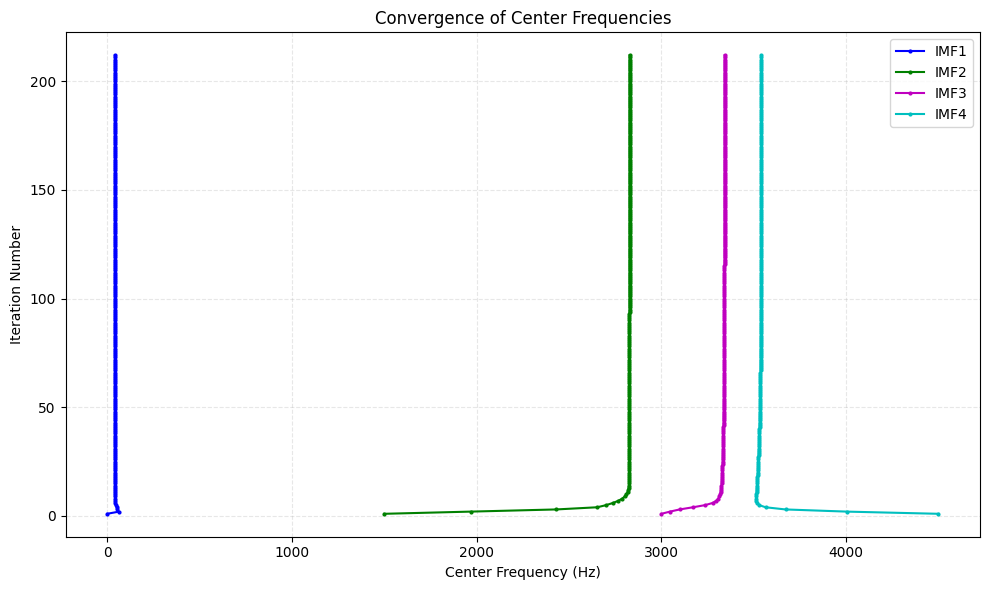

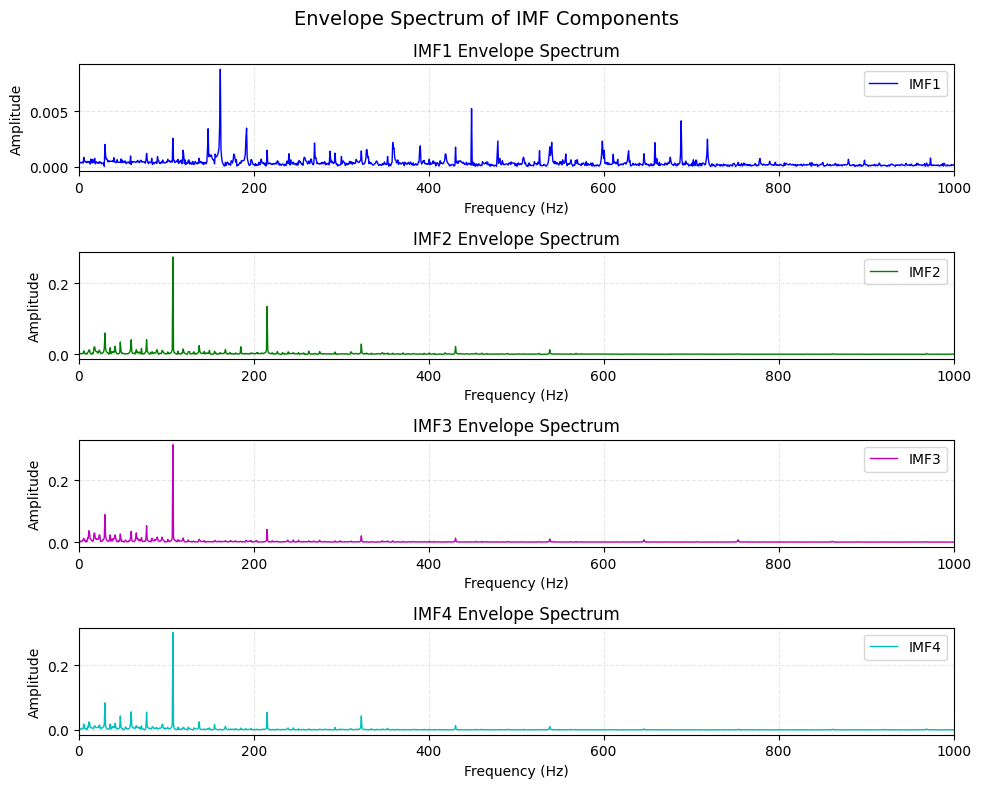

In [51]:
plot_IMF(u,u_hat,omega,K=4,data=data,f=12000)

In [52]:
data=loadmat('../../数据集/CRWU/12k Drive End Bearing Fault Data/Ball/0007/B007_0.mat')
data

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN, Created on: Mon Jan 31 13:55:05 2000',
 '__version__': '1.0',
 '__globals__': [],
 'X118_DE_time': array([[-0.0027614 ],
        [-0.09632403],
        [ 0.11370459],
        ...,
        [-0.07829373],
        [-0.14911545],
        [ 0.02111657]], shape=(122571, 1)),
 'X118_FE_time': array([[-0.24716182],
        [ 0.14279091],
        [ 0.00328727],
        ...,
        [ 0.01643636],
        [-0.03842   ],
        [-0.16806182]], shape=(122571, 1)),
 'X118_BA_time': array([[ 0.01553163],
        [ 0.01693994],
        [-0.03645507],
        ...,
        [ 0.03178754],
        [-0.03243134],
        [-0.0668343 ]], shape=(122571, 1)),
 'X118RPM': array([[1796]], dtype=uint16)}

In [53]:
data=data['X118_DE_time'].flatten()
data=data[:2**14]

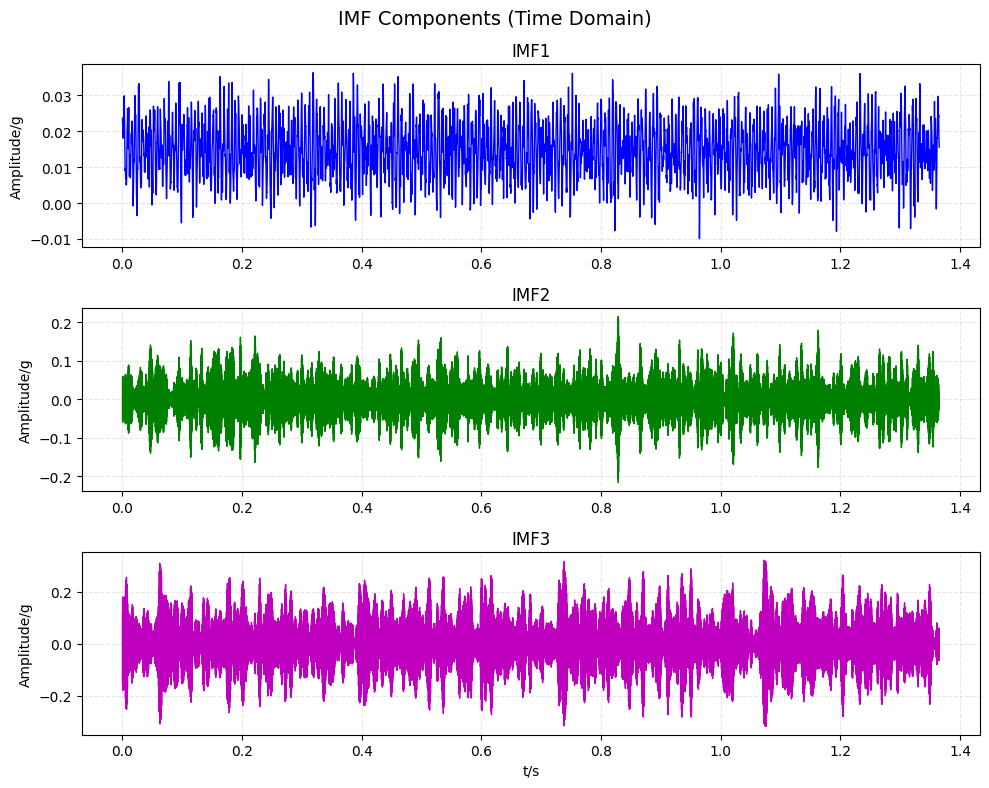

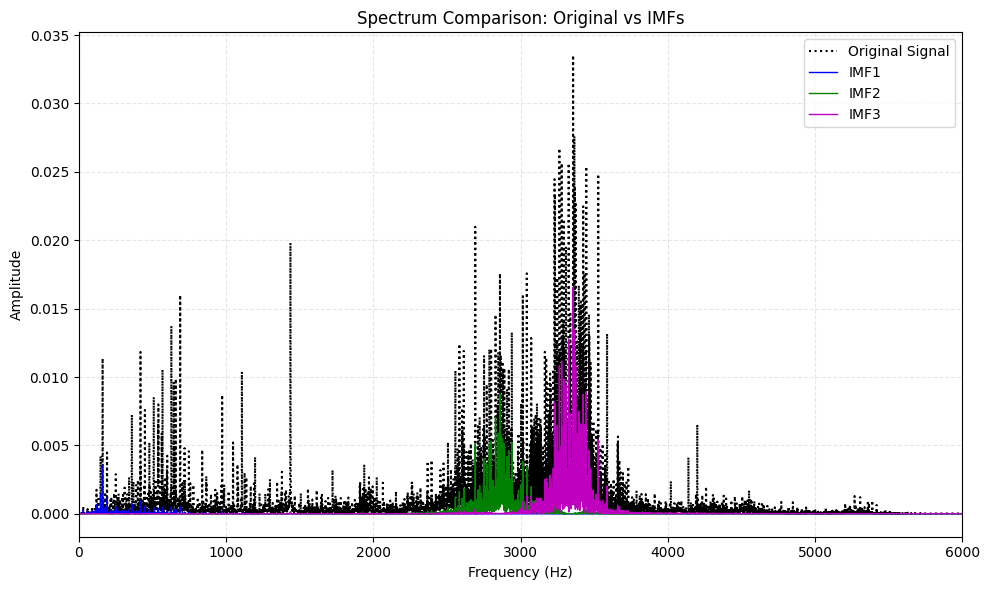

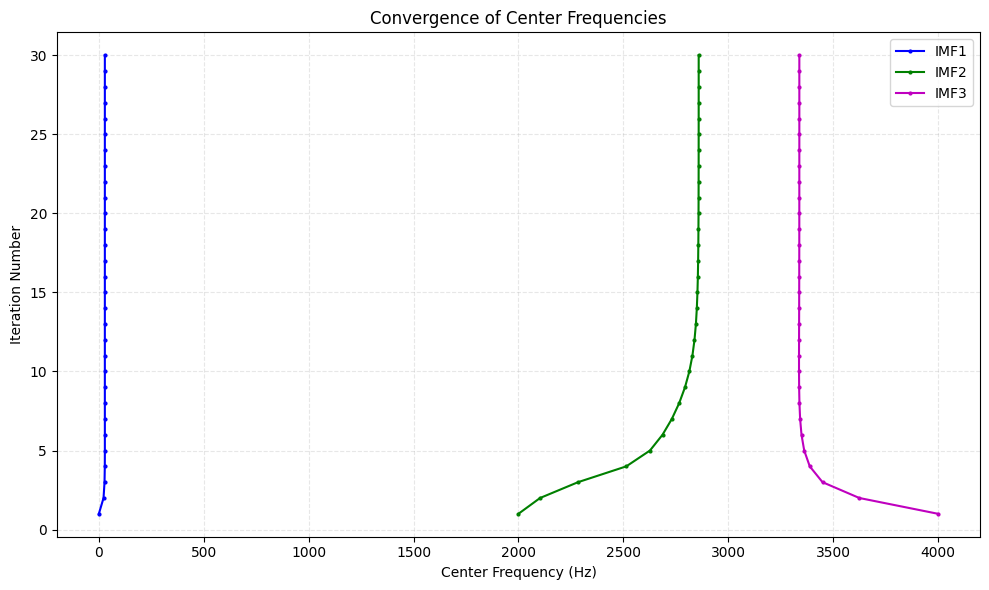

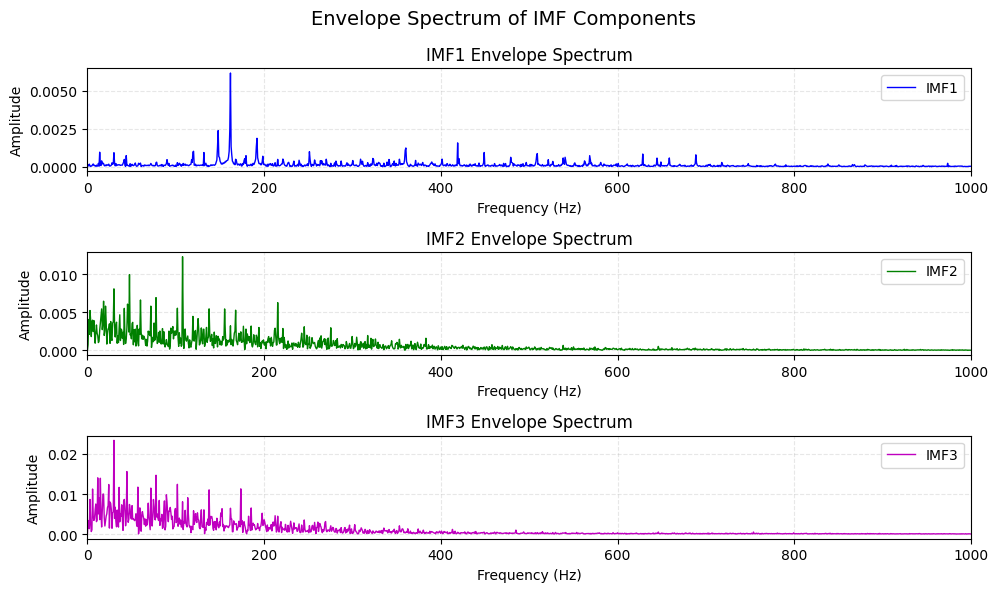

In [54]:
u, u_hat, omega = get_VMD(data, K=3, tol=1e-7, alpha=5000, tau=0, init=1, DC=0)
plot_IMF(u, u_hat, omega, K=3, data=data, f=12000)